   ### ML Practical 2
   #### Name: Ishika Sahare
   #### Section- Batch: B_B2
   #### Roll No.: 26

### Aim

To develop and implement Linear Regression models for predicting house prices using the USA Housing dataset.

---

### Objectives

- To understand the concept of Linear Regression.
- To load and analyze the USA Housing dataset.
- To perform data preprocessing and exploratory data analysis.
- To develop Simple and Multiple Linear Regression models.
- To evaluate model performance using regression metrics.
- To compare Ridge and Lasso Regression models.

---

### Dataset Used

- **USA Housing Dataset (CSV)**

---

### Date of Performance

**23/07/2026**

---

### Theory

#### What is Linear Regression?

Linear Regression is a supervised machine learning algorithm used to predict continuous numerical values. It establishes a linear relationship between independent variables (features) and a dependent variable (target). The algorithm finds the best-fit line that minimizes the prediction error and is commonly used for price prediction, sales forecasting, and trend analysis.

#### Types of Linear Regression

- Simple Linear Regression (SLR)
- Multiple Linear Regression (MLR)
- Ridge Regression
- Lasso Regression

---

### Materials Required

- Python 3.x
- Google Colab / Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- USA Housing Dataset (CSV)

---

### Procedure

- Import the required libraries.
- Load the USA Housing dataset.
- Explore the dataset using `head()`, `info()`, `describe()`, and `isnull()`.
- Remove unnecessary columns.
- Create box plots for data visualization.
- Split the dataset into training and testing sets.
- Train the Simple Linear Regression model.
- Train the Multiple Linear Regression model.
- Predict house prices using the trained models.
- Evaluate model performance using MAE, MSE, RMSE, and R² Score.
- Apply Ridge and Lasso Regression for comparison.

---

### GitHub URL

> Paste your GitHub repository link here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

### Output 1 – Load Dataset

#### Description

The USA Housing dataset is successfully loaded using the Pandas library. The `head()` function displays the first five rows of the dataset, providing an overview of the available features. This helps verify that the dataset has been imported correctly before further analysis.

In [2]:
df= pd.read_csv("USA_Housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


### Output 2 – Dataset Information

#### Description

The `info()` function provides detailed information about the dataset, including the total number of rows and columns, data types, non-null values, and memory usage. It helps understand the structure of the dataset and identify missing values before performing data preprocessing and model training.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


### Output 3 – Missing Values

#### Description

The missing value analysis checks each column of the dataset for null values. This step helps identify incomplete records that may require preprocessing before training the regression model. Handling missing values improves the quality and reliability of the predictions.

In [4]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [5]:
df.drop("Address",axis =1 , inplace=True)

In [6]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
dtype: int64

### Output 4 – Statistical Summary

#### Description

The `describe()` function generates statistical measures such as count, mean, standard deviation, minimum, maximum, and quartile values for all numerical features. These statistics provide insights into the overall distribution of the dataset and help identify unusual observations.

In [7]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [8]:
pd.set_option('display.float_format','{:.2f}'.format)

In [9]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.46,5.68,7.01,4.09,23086.80,1059033.56
1,79248.64,6.00,6.73,3.09,40173.07,1505890.91
2,61287.07,5.87,8.51,5.13,36882.16,1058987.99
3,63345.24,7.19,5.59,3.26,34310.24,1260616.81
4,59982.20,5.04,7.84,4.23,26354.11,630943.49


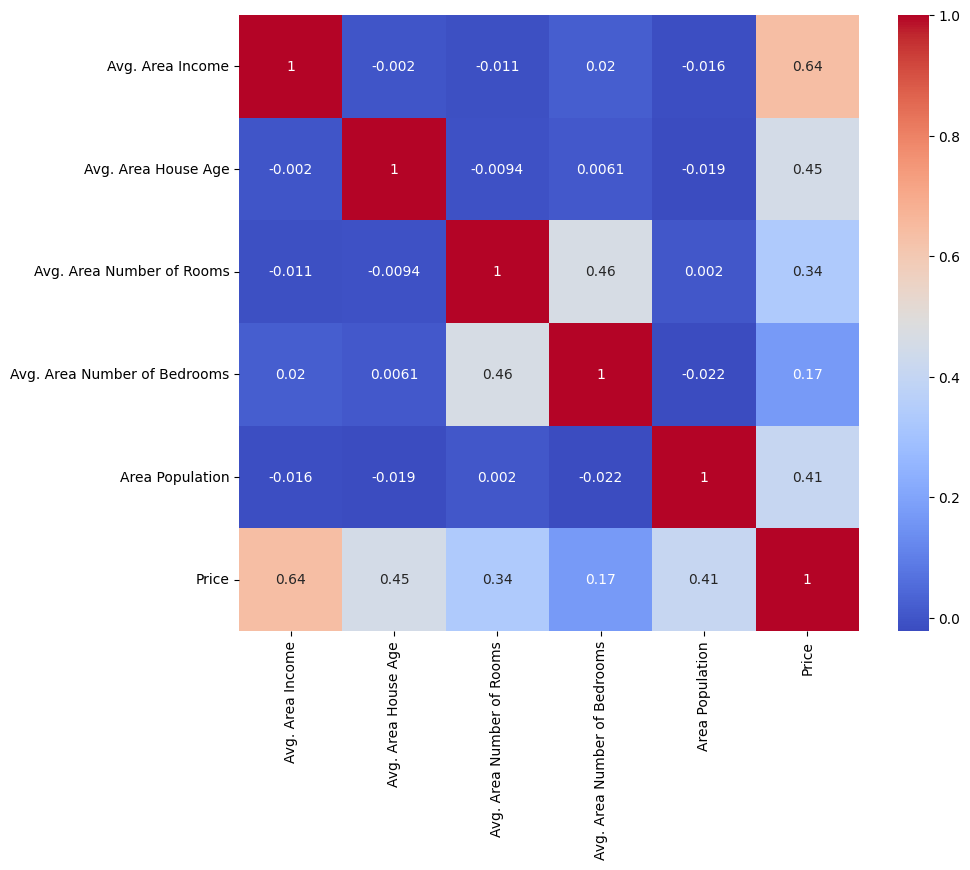

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.show()

### Output 5 – Box Plot

#### Description

The box plot visually represents the distribution of numerical features while highlighting the presence of outliers. It displays the median, quartiles, and spread of the data. This visualization helps identify extreme values that may affect the regression model.

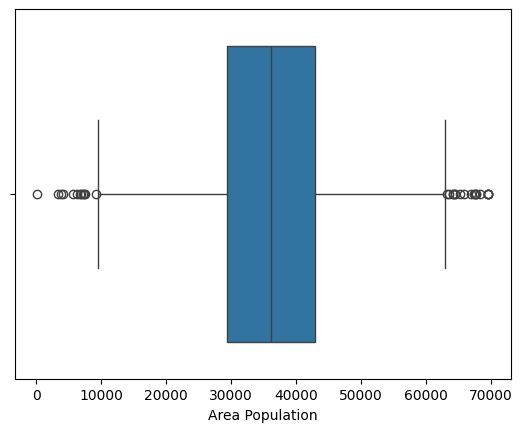

In [11]:
sns.boxplot(x=df["Area Population"])
plt.show()

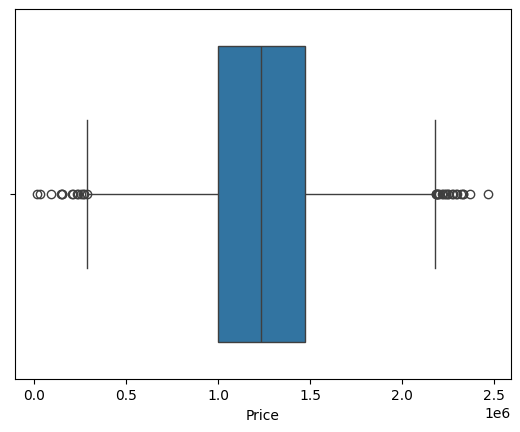

In [12]:
sns.boxplot(x=df["Price"])
plt.show()

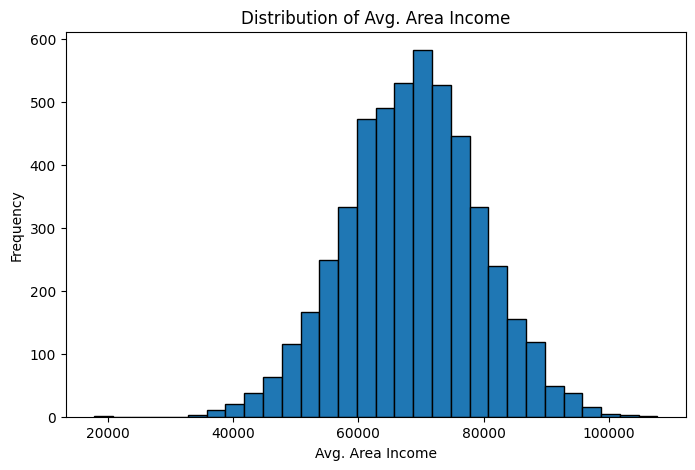

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Avg. Area Income'], bins=30, edgecolor='black')
plt.title('Distribution of Avg. Area Income')
plt.xlabel('Avg. Area Income')
plt.ylabel('Frequency')
plt.show()

# SLR

### Output 6 – Simple Linear Regression

#### Description

The Simple Linear Regression model is trained using a single independent feature to predict house prices. It learns the relationship between the predictor variable and the target variable by fitting the best possible straight line through the data points.

In [14]:
X = df[['Avg. Area Income']]
y = df['Price']

### Output 7 – Train-Test Split

#### Description

The dataset is divided into training and testing sets using the `train_test_split()` function. The training data is used to build the regression model, while the testing data is reserved to evaluate its performance on unseen data.

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=101)

In [16]:
from sklearn.linear_model import LinearRegression
slr_model = LinearRegression()
slr_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Output 8 – Model Prediction

#### Description

The trained Linear Regression model predicts house prices for the testing dataset. These predicted values are compared with the actual prices to determine how accurately the model performs and to evaluate its prediction capability.

In [17]:
y_pred =slr_model.predict(X_test)

In [18]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
#from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("Simple Linear Regression Results")
print("---------------------------------")

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R square score :",r2_score(y_test, y_pred))

Simple Linear Regression Results
---------------------------------
MAE : 217619.5644321996
MSE : 74402787880.48894
RMSE : 272768.7443247282
R square score : 0.41931484298724764


### Output 9 – Regression Line

#### Description

The regression line represents the best-fit line obtained after training the Simple Linear Regression model. It shows the relationship between the selected feature and house price, making it easier to understand the prediction trend.

In [19]:
print("Intercept:", slr_model.intercept_)
print("Slope:",slr_model.coef_[0])

Intercept: -215047.77188411704
Slope: 21.08845731042282


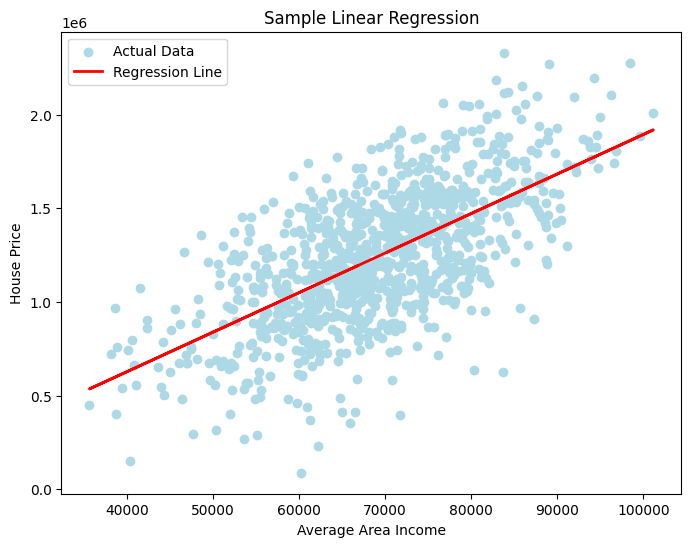

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(X_test,y_test,color="lightblue",label = "Actual Data")

plt.plot(X_test,y_pred,color="red",linewidth=2,label ='Regression Line')

plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.title("Sample Linear Regression")
plt.legend()

plt.show()

income = float(input("Enter Average Income: "))
new_data = np.array([[income]])
prediction = slr_model.predict(new_data)
print("Predict House Price =${:,.2f}".format(prediction[0]))

### MLR

### Output 10 – Multiple Linear Regression

#### Description

The Multiple Linear Regression model predicts house prices using multiple independent variables simultaneously. By considering several features together, the model captures more information and generally provides more accurate predictions.

In [22]:
X = df.drop(["Price"],axis=1)
y= df["Price"]

In [23]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42)

In [24]:
mlr = LinearRegression()
mlr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Output 11 – Feature Coefficients

#### Description

The regression coefficients indicate the contribution of each independent feature toward predicting house prices. These values help determine whether a feature has a positive or negative influence on the model's predictions.

In [25]:
coef = pd.DataFrame(mlr.coef_,X.columns,columns=["coefficient"])
coef

,coefficient
Avg. Area Income,21.65
Avg. Area House Age,164666.48
Avg. Area Number of Rooms,119624.01
Avg. Area Number of Bedrooms,2440.38
Area Population,15.27


### Output 12 – Model Evaluation

#### Description

The performance of the regression model is evaluated using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These metrics measure prediction accuracy and the overall effectiveness of the model.

In [26]:
print("MAE :",mean_absolute_error(y_test,y_pred))
print("MSE :", mean_squared_error(y_test,y_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,y_pred)))
print("R^2 :" , r2_score(y_test,y_pred))

MAE : 336261.13966751244
MSE : 175975144733.36935
RMSE : 419493.9150135188
R^2 : -0.43031484332658376


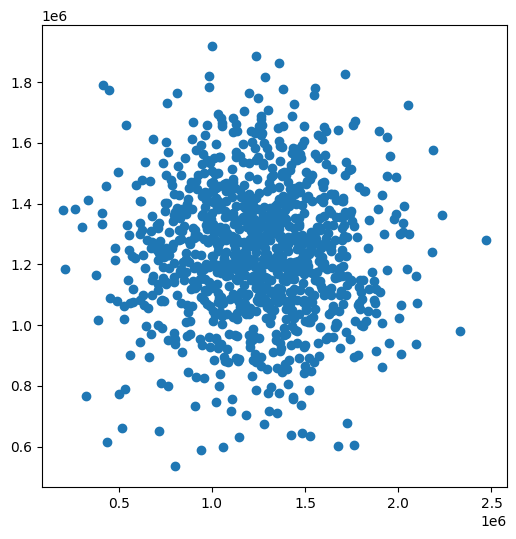

In [27]:
plt.figure(figsize =(6,6))
plt.scatter(y_test,y_pred)

### Output 13 – Actual vs Predicted Plot

#### Description

The Actual vs Predicted plot compares the actual house prices with the values predicted by the regression model. A closer alignment between the two values indicates better prediction accuracy and overall model performance.

In [28]:
predictions= mlr.predict(X_test)

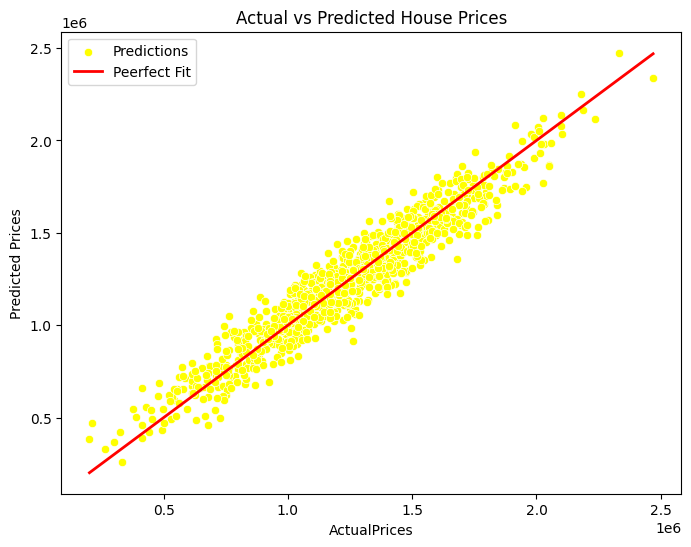

In [29]:
plt.figure(figsize =(8,6))
sns.scatterplot(x=y_test,y=predictions, color="yellow",label="Predictions")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color="red",linewidth =2,label = "Peerfect Fit")

plt.title('Actual vs Predicted House Prices')
plt.xlabel('ActualPrices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.show()

In [30]:
income = float(input("Enter Average Area Income:"))
house_age = float(input("Enter Average Area House Age : "))
rooms = float(input("Enter Average Area Number Of Rooms: "))
bedrooms = float(input("Enter Average Area Number of Bedrooms: "))
population = float(input("Enter Area Population:"))

test_input = np.array([[income,house_age,rooms,bedrooms,population]])
predicted_price =mlr.predict(test_input)
print("\n Predicted Housr Price:${:,.2f}".format(predicted_price[0]))

Enter Average Area Income: 652365
Enter Average Area House Age :  12
Enter Average Area Number Of Rooms:  5
Enter Average Area Number of Bedrooms:  3
Enter Area Population: 1523654



 Predicted Housr Price:$37,338,181.41


C:\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Ridge Regression

### Output 14 – Ridge Regression

#### Description

Ridge Regression applies L2 regularization to reduce overfitting by controlling the magnitude of the regression coefficients. This improves the model's stability and enhances its performance on unseen data.

In [31]:
from sklearn.model_selection import GridSearchCV

In [32]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train,y_train)
ridge_pred = ridge.predict(X_test)
print("Default Ridge R^2 :" ,r2_score(y_test,ridge_pred))

Default Ridge R^2 : 0.9179914220241199


In [33]:
param_grid = {'alpha':[0.001,0.01,0.1,1,10,100]}

In [34]:
grid_ridge = GridSearchCV(estimator=Ridge(),param_grid=param_grid,scoring ='r2',cv=5)

In [35]:
grid_ridge.fit(X_train,y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1


In [36]:
print("Best Alpha:",grid_ridge.best_params_)

Best Alpha: {'alpha': 1}


In [37]:
print(grid_ridge.best_score_)

0.9174133082098411


In [38]:
best_ridge = grid_ridge.best_estimator_
ridge_pred = best_ridge.predict(X_test)

In [39]:
print("MAE :",mean_absolute_error(y_test,ridge_pred))
print("MSE :", mean_squared_error(y_test,ridge_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,ridge_pred)))
print("R^2 :" , r2_score(y_test,ridge_pred))

MAE : 80882.08068490674
MSE : 10089716572.554762
RMSE : 100447.5812180401
R^2 : 0.9179914220241199


### Output 15 – Lasso Regression

#### Description

Lasso Regression uses L1 regularization to improve the regression model while also performing feature selection. It reduces the coefficients of less important features toward zero, resulting in a simpler and more interpretable model.

In [40]:
from sklearn.linear_model import Lasso

param_grid = { 'alpha':[0.001,0.01,0.1,1,10]}

In [41]:
grid_lasso = GridSearchCV(Lasso(max_iter=5000),param_grid,cv=5,scoring='r2')

grid_lasso.fit(X_train,y_train)

,estimator,Lasso(max_iter=5000)
,param_grid,"{'alpha': [0.001, 0.01, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,10


In [42]:
print(grid_lasso.best_params_)

{'alpha': 10}


In [43]:
lasso_pred = grid_lasso.predict(X_test)
print(r2_score(y_test,ridge_pred))

0.9179914220241199


In [44]:
print("MAE :",mean_absolute_error(y_test,lasso_pred))
print("MSE :", mean_squared_error(y_test,lasso_pred))
print("RMSE :",np.sqrt(mean_squared_error(y_test,lasso_pred)))
print("R^2 :" , r2_score(y_test,lasso_pred))

MAE : 80879.71931333185
MSE : 10089130528.622488
RMSE : 100444.66401269153
R^2 : 0.9179961853521253
